STEP 1 — LOAD DATASET


CELL 1 — Import Libraries

In [3]:
# CELL 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CELL 2 — Load Dataset

In [4]:
# CELL 2: Load dataset

df = pd.read_csv('../data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


STEP 2 — UNDERSTAND DATA

CELL 3 — Dataset Info

In [5]:
# CELL 3: Understand dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


CELL 4 — Missing Values

In [6]:
# CELL 4: Check missing values

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

STEP 3 — EDA (GRAPHS)

Now we visualize patterns

CELL 5 — Survival Count

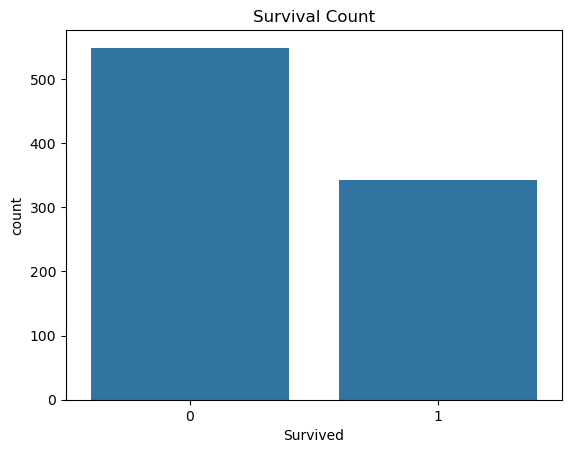

In [7]:
# CELL 5: Survival distribution

sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

CELL 6 — Survival by Gender

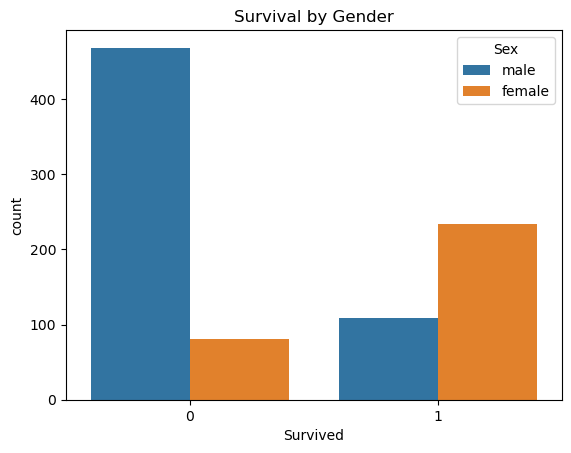

In [8]:
# CELL 6: Survival by gender

sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender")
plt.show()

CELL 7 — Survival by Class

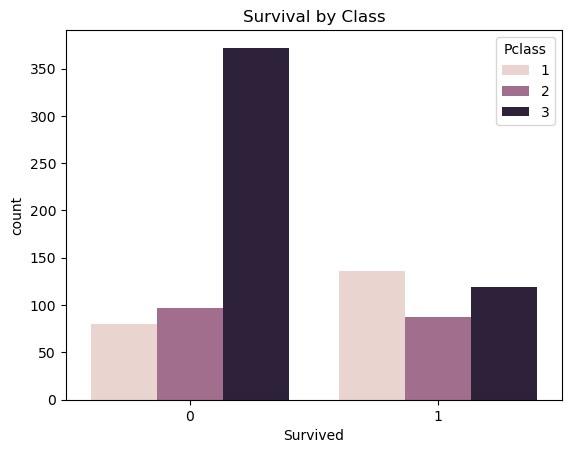

In [9]:
# CELL 7: Survival by passenger class

sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title("Survival by Class")
plt.show()

CELL 7B → Correlation matrix

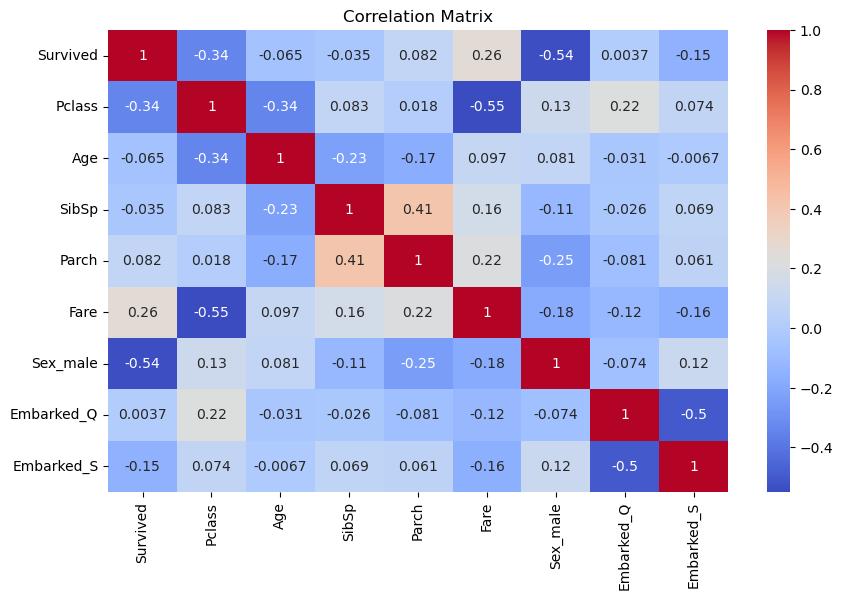

In [16]:
# CELL 7B: Correlation Matrix

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

STEP 4 — DATA CLEANING

CELL 8 — Drop Unnecessary Columns

In [10]:
# CELL 8: Drop irrelevant columns

df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

CELL 9 — Handle Missing Values

In [11]:
# CELL 9: Fill missing values

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

STEP 5 — FEATURE ENGINEERING

CELL 10 — Encode Categorical Variables

In [12]:
# CELL 10: Convert text to numbers

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


STEP 6 — TRAIN / TEST SPLIT

CELL 11

In [13]:
# CELL 11: Split data

from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

STEP 7 — LOGISTIC REGRESSION MODEL

CELL 12

In [14]:
# CELL 12: Train model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


STEP 8 — PREDICTIONS

CELL 13

In [15]:
# CELL 13: Predictions

y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


CELL 13B → Probability predictions

In [17]:
# CELL 13B: Probability predictions

y_prob = model.predict_proba(X_test)[:,1]

print(y_prob[:10])

[0.11001683 0.22214772 0.13453754 0.88618535 0.73628593 0.93120823
 0.68412991 0.09080719 0.75760986 0.9218138 ]


STEP 8B — PROBABILITY DISTRIBUTION (GRAPH)

CELL 13C

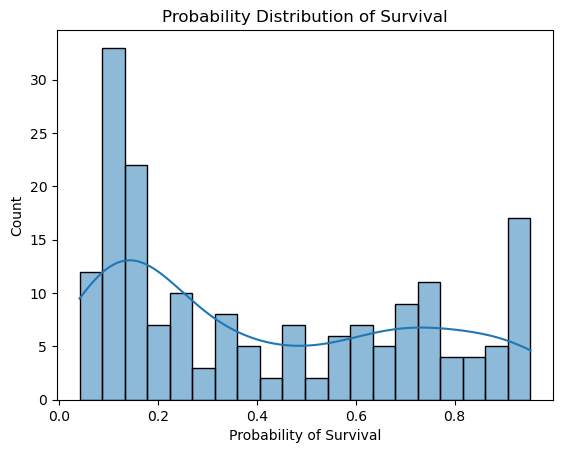

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(y_prob, bins=20, kde=True)
plt.title("Probability Distribution of Survival")
plt.xlabel("Probability of Survival")
plt.ylabel("Count")
plt.show()

STEP 8C — THRESHOLD VISUALIZATION

CELL 13D

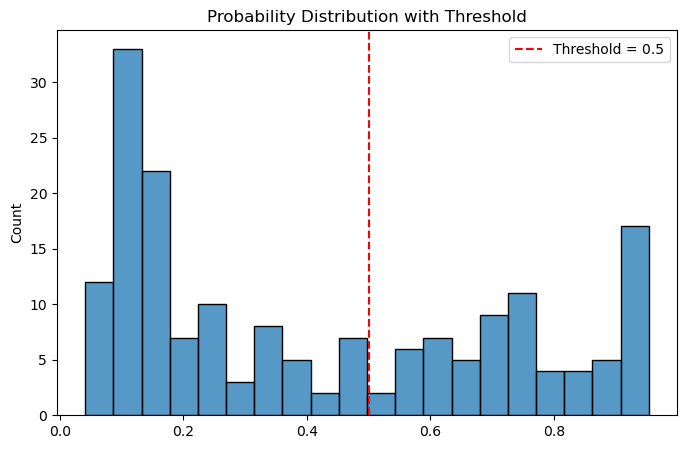

In [19]:
threshold = 0.5

plt.figure(figsize=(8,5))
sns.histplot(y_prob, bins=20)

plt.axvline(threshold, color='red', linestyle='--', label='Threshold = 0.5')

plt.title("Probability Distribution with Threshold")
plt.legend()
plt.show()

STEP 9A — CONFUSION MATRIX (CORE EVALUATION)

CELL 14 — Confusion Matrix + Metrics

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877

Confusion Matrix:
 [[90 15]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



STEP 9B — CONFUSION MATRIX GRAPH

CELL 15 — Heatmap Visualization

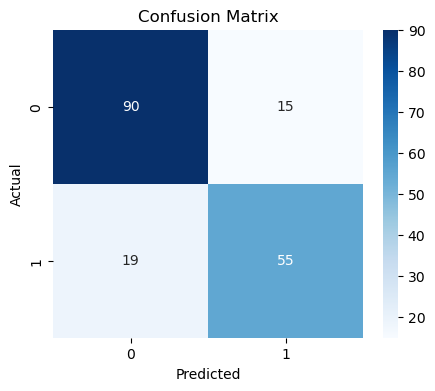

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

STEP 9C — ROC CURVE

CELL 16 — ROC Curve

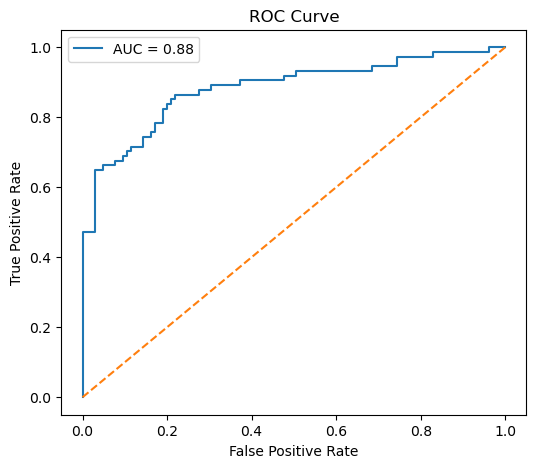

In [22]:
from sklearn.metrics import roc_curve, auc

# probability values
y_prob = model.predict_proba(X_test)[:,1]

# compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

STEP 10 — CONCLUSION

# 🚢 Titanic Classification Project – Conclusion

## 📌 Objective
The goal of this project was to build a machine learning model using Logistic Regression to predict whether a passenger survived the Titanic disaster.

---

## 📊 Workflow Followed

The project followed a complete machine learning pipeline:

1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Train/Test Split
6. Model Training (Logistic Regression)
7. Predictions
8. Model Evaluation (Confusion Matrix + ROC Curve)

---

## 🧹 Data Preprocessing
- Missing values in Age were filled using median
- Missing values in Embarked were filled using mode
- Cabin column was dropped due to excessive missing data
- Categorical variables were encoded using one-hot encoding

---

## 🤖 Model Performance
The Logistic Regression model was evaluated using:

- Accuracy Score
- Confusion Matrix
- ROC Curve

The model performed reasonably well in predicting survival outcomes based on passenger features.

---

## 📈 Key Insights
- Gender was a strong predictor of survival
- Passenger class influenced survival chances
- Higher fare passengers had better survival probability

---

## 🎯 Final Conclusion
This project successfully demonstrates a complete machine learning classification pipeline using Logistic Regression, from data preprocessing to model evaluation.

It provides a strong foundation for understanding supervised learning and binary classification problems.